# Simple Spread Strategy — TFEX USD Futures vs Binance TH USDTTHB

**No z-score. No statistics. Only the spread in THB and %, based on your real captured data.**

What this notebook does:

1. Loads **real bid/ask quotes** from your own Railway Postgres logger (`bidask_snapshots` table).
2. Aligns TFEX `USDM26` and Binance TH `USDTTHB` quotes in time.
3. Computes the spread and the **executable edge** (what you could really earn crossing both books).
4. Subtracts **real fees** and shows honestly if any trade was possible.
5. Runs a very simple backtest: *enter when the gap pays more than all costs, exit when the gap is gone.*
6. Studies **orderbook liquidity** (10 levels of depth) to answer: *how much money can this strategy use?*

> **Honest note**: this is statistical arbitrage (a bet on mean-reversion), not risk-free arbitrage.
> See `ARBITRAGE_TUTORIAL.md` for the full risk discussion. This notebook places **no orders**.

## The strategy in plain words

Both markets price the same thing: **USD in THB**.

```text
spread = Binance TH price - TFEX price
```

- Binance **higher** than TFEX → sell USDT on Binance (at the **bid**), buy USD futures on TFEX (at the **ask**).
- Binance **lower** than TFEX → buy USDT on Binance (at the **ask**), sell USD futures on TFEX (at the **bid**).

The money you can actually capture is the **executable edge** (using bid/ask you can really trade,
not mid prices):

```text
edge_short_usdt = binance_bid - tfex_ask    (Binance expensive)
edge_long_usdt  = tfex_bid  - binance_ask   (Binance cheap)
```

**Entry rule**: edge − all round-trip costs > buffer → open the pair trade.
**Exit rule**: the gap is gone (closing the position costs almost nothing) → close both legs.

That is the whole strategy. No z-score needed.

## Setup

Run from the project root. Needs `.env` with `DATABASE_URL=postgresql://...` (your Railway database).

```bash
uv sync
uv run jupyter lab
```

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import psycopg2
from dotenv import load_dotenv

warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
pd.set_option("display.width", 160)

In [2]:
# ---------- Configuration (all plain numbers, tune them here) ----------
TFEX_SYMBOL = "USDM26"            # active TFEX USD futures contract
BINANCE_SYMBOL = "USDTTHB"

MAX_QUOTE_AGE_SECONDS = 2         # only compare quotes closer than this in time (project rule)

# Costs, in THB per 1 USD of position (1 TFEX contract = 1,000 USD)
BINANCE_FEE_RATE = 0.0025         # 0.25% per side = Binance TH base tier for USDTTHB. Use your real tier!
TFEX_COST_PER_SIDE_THB = 0.025    # ~THB 25 per contract per side (brokerage + exchange fee + VAT) / 1000 USD

ENTRY_BUFFER_THB = 0.01           # extra edge required on top of costs before entering (slippage safety)
EXIT_TOLERANCE_THB = 0.01         # exit when closing the trade costs less than this per USD

## Step 1 — Load real quotes from your database

Your Railway service stores every bid/ask update in `bidask_snapshots` + `bidask_levels`.
We pull the **best bid and best ask (level 1)** for both markets.

In [3]:
load_dotenv()
conn = psycopg2.connect(os.environ["DATABASE_URL"])

QUERY = """
SELECT s.source, s.received_at,
  MAX(l.price) FILTER (WHERE l.side = 'bid' AND l.level = 1) AS bid,
  MAX(l.price) FILTER (WHERE l.side = 'ask' AND l.level = 1) AS ask
FROM bidask_snapshots s
JOIN bidask_levels l ON l.snapshot_id = s.id
WHERE (s.source = 'settrade'   AND s.symbol = %(tfex)s)
   OR (s.source = 'binance_th' AND s.symbol = %(binance)s)
GROUP BY s.id, s.source, s.received_at
ORDER BY s.received_at
"""

raw = pd.read_sql(QUERY, conn, params={"tfex": TFEX_SYMBOL, "binance": BINANCE_SYMBOL})
conn.close()

raw["received_at"] = pd.to_datetime(raw["received_at"], utc=True).dt.tz_convert("Asia/Bangkok")
raw[["bid", "ask"]] = raw[["bid", "ask"]].astype(float)

for source, grp in raw.groupby("source"):
    print(f"{source:>11}: {len(grp):,} quotes | {grp.received_at.min()} -> {grp.received_at.max()}")

 binance_th: 17,234 quotes | 2026-06-11 12:47:39.709905+07:00 -> 2026-06-12 17:00:26.364516+07:00
   settrade: 19,298 quotes | 2026-06-11 12:39:39.176473+07:00 -> 2026-06-12 16:58:20.126154+07:00


## Step 2 — Align the two markets in time

The two feeds tick at different moments. For every Binance quote we attach the **most recent**
TFEX quote, but only if it is younger than `MAX_QUOTE_AGE_SECONDS`. Older quotes are dropped —
comparing a fresh price with a stale price creates fake spreads.

In [4]:
tfex = (raw[raw.source == "settrade"]
        .rename(columns={"bid": "tfex_bid", "ask": "tfex_ask"})
        [["received_at", "tfex_bid", "tfex_ask"]]
        .sort_values("received_at"))
binance = (raw[raw.source == "binance_th"]
           .rename(columns={"bid": "binance_bid", "ask": "binance_ask"})
           [["received_at", "binance_bid", "binance_ask"]]
           .sort_values("received_at"))

pairs = pd.merge_asof(
    binance, tfex,
    on="received_at",
    direction="backward",
    tolerance=pd.Timedelta(seconds=MAX_QUOTE_AGE_SECONDS),
).dropna().reset_index(drop=True)

print(f"Matched quote pairs: {len(pairs):,}")
print(f"Window (Bangkok time): {pairs.received_at.min()} -> {pairs.received_at.max()}")

Matched quote pairs: 7,648
Window (Bangkok time): 2026-06-12 11:40:04.946531+07:00 -> 2026-06-12 16:58:22.029778+07:00


## Step 3 — Compute the spread and the executable edges

| Column | Meaning |
|---|---|
| `mid_spread` | Binance mid − TFEX mid, in THB (general view) |
| `mid_spread_pct` | same, in % of TFEX mid |
| `edge_short_usdt` | THB you capture per USD selling USDT on Binance + buying TFEX, **before fees** |
| `edge_long_usdt` | THB you capture per USD buying USDT on Binance + selling TFEX, **before fees** |

Positive edge = the books really cross. Negative edge = you would pay the spread to enter.

In [5]:
pairs["binance_mid"] = (pairs.binance_bid + pairs.binance_ask) / 2
pairs["tfex_mid"] = (pairs.tfex_bid + pairs.tfex_ask) / 2
pairs["mid_spread"] = pairs.binance_mid - pairs.tfex_mid
pairs["mid_spread_pct"] = pairs.mid_spread / pairs.tfex_mid * 100

pairs["edge_short_usdt"] = pairs.binance_bid - pairs.tfex_ask
pairs["edge_long_usdt"] = pairs.tfex_bid - pairs.binance_ask

print(pairs[["mid_spread", "mid_spread_pct", "edge_short_usdt", "edge_long_usdt"]]
      .describe().round(4).to_string())
pairs.tail(3)

       mid_spread  mid_spread_pct  edge_short_usdt  edge_long_usdt
count   7648.0000       7648.0000        7648.0000       7648.0000
mean       0.0102          0.0311          -0.0008         -0.0212
std        0.0138          0.0423           0.0145          0.0135
min       -0.0200         -0.0612          -0.0400         -0.0700
25%        0.0000          0.0000          -0.0100         -0.0300
50%        0.0100          0.0305           0.0000         -0.0200
75%        0.0200          0.0612           0.0100         -0.0100
max        0.0550          0.1686           0.0400          0.0100


,received_at,binance_bid,binance_ask,tfex_bid,tfex_ask,binance_mid,tfex_mid,mid_spread,mid_spread_pct,edge_short_usdt,edge_long_usdt
7645,2026-06-12 16:55:01.760838+07:00,32.67,32.68,32.62,32.64,32.675,32.63,0.045,0.137910,0.03,-0.06
7646,2026-06-12 16:58:20.795006+07:00,32.68,32.69,32.62,32.64,32.685,32.63,0.055,0.168557,0.04,-0.07
7647,2026-06-12 16:58:22.029778+07:00,32.68,32.69,32.62,32.64,32.685,32.63,0.055,0.168557,0.04,-0.07


## Step 4 — Look at the data

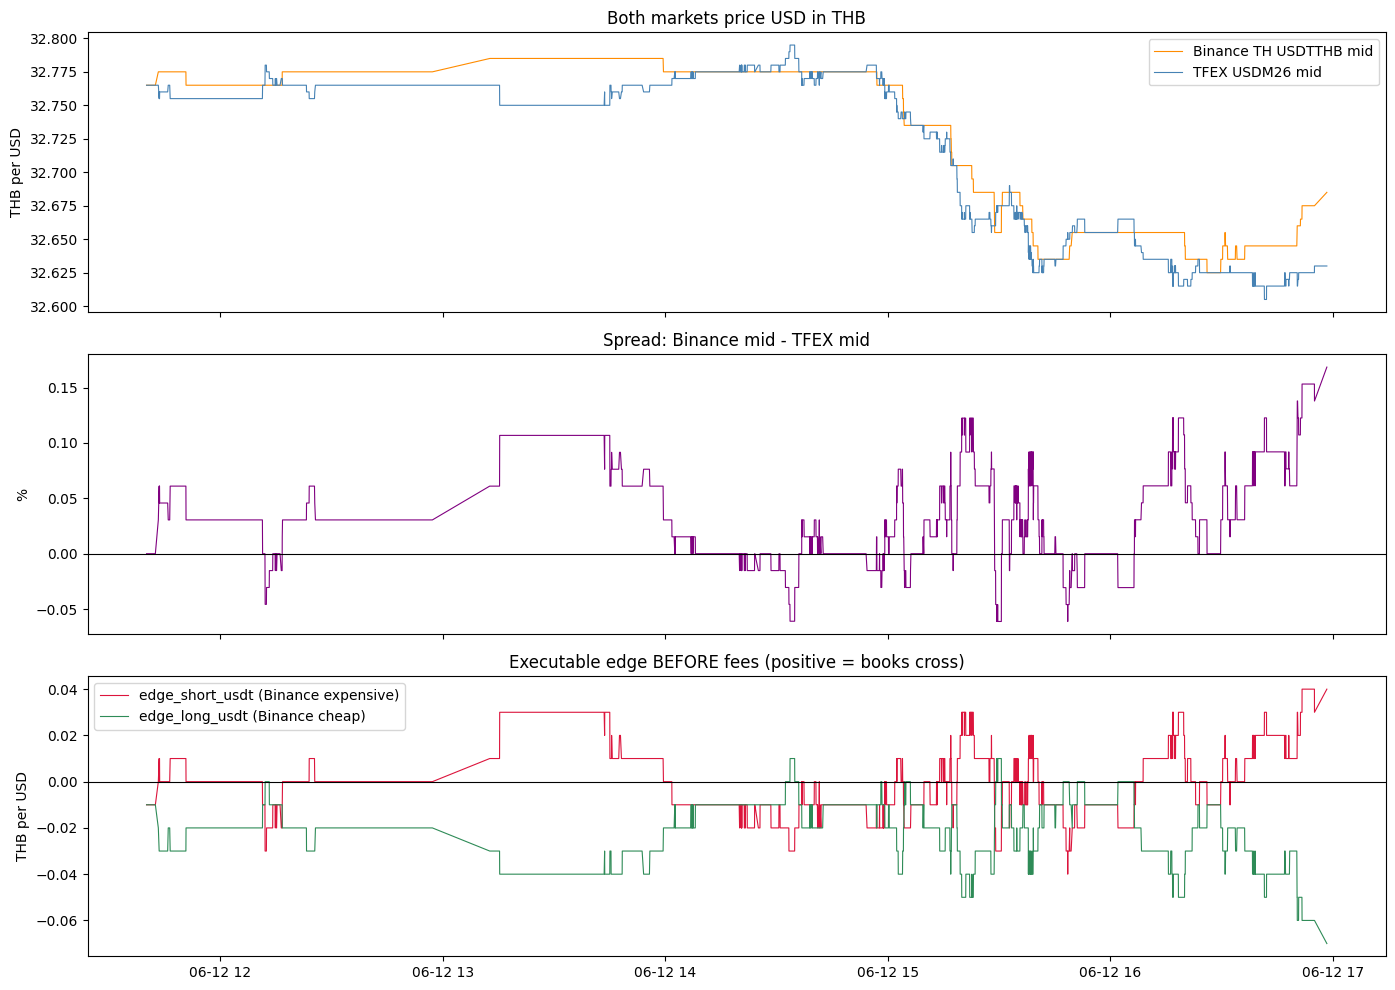

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
ts = pairs.received_at

axes[0].plot(ts, pairs.binance_mid, color="darkorange", lw=0.8, label=f"Binance TH {BINANCE_SYMBOL} mid")
axes[0].plot(ts, pairs.tfex_mid, color="steelblue", lw=0.8, label=f"TFEX {TFEX_SYMBOL} mid")
axes[0].set_title("Both markets price USD in THB")
axes[0].set_ylabel("THB per USD")
axes[0].legend()

axes[1].plot(ts, pairs.mid_spread_pct, color="purple", lw=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Spread: Binance mid - TFEX mid")
axes[1].set_ylabel("%")

axes[2].plot(ts, pairs.edge_short_usdt, color="crimson", lw=0.8, label="edge_short_usdt (Binance expensive)")
axes[2].plot(ts, pairs.edge_long_usdt, color="seagreen", lw=0.8, label="edge_long_usdt (Binance cheap)")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("Executable edge BEFORE fees (positive = books cross)")
axes[2].set_ylabel("THB per USD")
axes[2].legend()

plt.tight_layout()
plt.show()

## Step 5 — Costs (this is where most "opportunities" die)

Round trip = open the pair trade + close it later. Per 1 USD of position:

- Binance: fee rate × price, paid **twice** (entry + exit)
- TFEX: fixed THB per contract, paid **twice**, divided by 1,000 USD

**Do not confuse tick size with fees.** The tick size is the *minimum price step* the contract
can move — a market rule, not money you pay. Fees are brokerage + exchange fee + VAT.
Cheat sheet for the TFEX contracts in your database:

| Contract | Quotation | Tick size | Tick value per contract | Size / multiplier |
|---|---|---|---|---|
| USD Futures (`USDM26`) | THB per USD, 2 dp | THB 0.01 | THB 10 | 1,000 USD |
| Mini Gold Online (`MGOM26`) | USD per troy oz, 1 dp | 0.1 USD | THB 3 | 30 (quanto) |
| Gold Online (`GOM26`) | USD per troy oz, 1 dp | 0.1 USD | THB 30 | 300 (quanto) |

For this USD pair: one tick (0.01 THB/USD) = 10 THB per contract. The edges you saw in Step 3
move in exactly these 0.01 steps — that is why `edge` values are always 0.01, 0.02, 0.03 …

In [7]:
avg_price = pairs.binance_mid.mean()
binance_round_trip = 2 * BINANCE_FEE_RATE * avg_price
tfex_round_trip = 2 * TFEX_COST_PER_SIDE_THB
ROUND_TRIP_COST_THB = binance_round_trip + tfex_round_trip

best_edge = max(pairs.edge_short_usdt.max(), pairs.edge_long_usdt.max())

print(f"Average price                 : {avg_price:.2f} THB/USD")
print(f"Binance round trip (2 sides)  : {binance_round_trip:.4f} THB/USD  (fee rate {BINANCE_FEE_RATE:.4%}/side)")
print(f"TFEX round trip (2 sides)     : {tfex_round_trip:.4f} THB/USD")
print(f"TOTAL round-trip cost         : {ROUND_TRIP_COST_THB:.4f} THB/USD "
      f"(= {ROUND_TRIP_COST_THB * 1000:,.0f} THB per contract)")
print()
print(f"Best gross edge in this data  : {best_edge:.4f} THB/USD")
needed = ROUND_TRIP_COST_THB + ENTRY_BUFFER_THB
print(f"Edge needed to enter a trade  : {needed:.4f} THB/USD (costs + buffer)")
print()
if best_edge >= needed:
    print("=> Some moments in this data DID pay more than full costs. The backtest below will trade them.")
else:
    print("=> HONEST RESULT: in this data window, NO moment paid more than full costs.")
    print("   The strategy is correct but the edge was too small at this fee tier. Keep collecting data;")
    print("   the target is episodic spikes (like 27 May 2026), and a better Binance fee tier helps a lot.")

Average price                 : 32.72 THB/USD
Binance round trip (2 sides)  : 0.1636 THB/USD  (fee rate 0.2500%/side)
TFEX round trip (2 sides)     : 0.0500 THB/USD
TOTAL round-trip cost         : 0.2136 THB/USD (= 214 THB per contract)

Best gross edge in this data  : 0.0400 THB/USD
Edge needed to enter a trade  : 0.2236 THB/USD (costs + buffer)

=> HONEST RESULT: in this data window, NO moment paid more than full costs.
   The strategy is correct but the edge was too small at this fee tier. Keep collecting data;
   the target is episodic spikes (like 27 May 2026), and a better Binance fee tier helps a lot.


## Step 6 — Simple backtest (the whole strategy, no z-score)

Rules, exactly as stated at the top:

1. **Flat?** If `edge − round-trip costs ≥ ENTRY_BUFFER_THB` → enter (either direction).
2. **In a trade?** If closing the position costs less than `EXIT_TOLERANCE_THB` per USD → exit.
3. One position at a time. P&L is computed from the **real bid/ask at entry and exit**:

```text
pnl_per_usd = edge_at_entry + closing_edge_at_exit - round_trip_costs
```

In [8]:
def run_backtest(df: pd.DataFrame, round_trip_cost: float, entry_buffer: float,
                 exit_tolerance: float) -> tuple[pd.DataFrame, dict | None]:
    """One-position-at-a-time spread backtest on real quote pairs."""
    position = None
    trades = []
    for row in df.itertuples():
        if position is None:
            if row.edge_short_usdt - round_trip_cost >= entry_buffer:
                position = {"side": "short_usdt_binance_long_tfex",
                            "entry_ts": row.received_at, "entry_edge": row.edge_short_usdt}
            elif row.edge_long_usdt - round_trip_cost >= entry_buffer:
                position = {"side": "long_usdt_binance_short_tfex",
                            "entry_ts": row.received_at, "entry_edge": row.edge_long_usdt}
        else:
            closing_edge = (row.edge_long_usdt if position["side"].startswith("short")
                            else row.edge_short_usdt)
            if closing_edge >= -exit_tolerance:
                pnl = position["entry_edge"] + closing_edge - round_trip_cost
                trades.append({**position, "exit_ts": row.received_at,
                               "exit_edge": closing_edge,
                               "pnl_thb_per_usd": pnl,
                               "pnl_thb_per_contract": pnl * 1000})
                position = None
    return pd.DataFrame(trades), position


trades, still_open = run_backtest(pairs, ROUND_TRIP_COST_THB, ENTRY_BUFFER_THB, EXIT_TOLERANCE_THB)

if trades.empty and still_open is None:
    print("0 trades with REAL costs in this window. That is the honest answer for this sample.")
    print("Below: the 10 best moments that came closest to a real opportunity.")
    top = pairs.assign(best_edge=pairs[["edge_short_usdt", "edge_long_usdt"]].max(axis=1))
    top10 = top.nlargest(10, "best_edge")[["received_at", "binance_bid", "binance_ask",
                                           "tfex_bid", "tfex_ask", "best_edge", "mid_spread_pct"]]
    num_cols = top10.select_dtypes("number").columns
    top10[num_cols] = top10[num_cols].round(4)
    display(top10)
else:
    if still_open is not None:
        print(f"Note: position still open at end of data: {still_open}")
    print(f"Trades: {len(trades)} | total P&L: {trades.pnl_thb_per_contract.sum():,.0f} THB per contract")
    display(trades.round(4))

0 trades with REAL costs in this window. That is the honest answer for this sample.
Below: the 10 best moments that came closest to a real opportunity.


,received_at,binance_bid,binance_ask,tfex_bid,tfex_ask,best_edge,mid_spread_pct
7580,2026-06-12 16:51:40.939842+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7581,2026-06-12 16:51:54.270285+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7582,2026-06-12 16:51:55.371428+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7583,2026-06-12 16:52:02.154585+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7584,2026-06-12 16:52:03.254624+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7585,2026-06-12 16:52:14.290018+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7586,2026-06-12 16:52:15.387898+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7587,2026-06-12 16:52:16.542787+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7588,2026-06-12 16:52:26.798580+07:00,32.67,32.68,32.62,32.63,0.04,0.1533
7589,2026-06-12 16:52:28.035435+07:00,32.67,32.68,32.62,32.63,0.04,0.1533


## Step 7 — Demo mode: see the mechanics work (fees set to zero)

With real fees the sample above may show zero trades. To **see** how entry/exit behaves on the same
real data, run the identical backtest with costs at zero and a small 0.02 THB entry edge.

> ⚠️ This is **educational only** — these "profits" ignore fees and could never be captured at the
> base fee tier. It exists so you can watch the rules trigger on real quote movements.

Demo trades (fees ignored): 3


,side,entry_ts,entry_edge,exit_ts,exit_edge,pnl_thb_per_usd,pnl_thb_per_contract
0,short_usdt_binance_long_tfex,2026-06-12 13:15:17.692995+07:00,0.03,2026-06-12 14:02:31.883007+07:00,-0.01,0.02,20.0
1,short_usdt_binance_long_tfex,2026-06-12 15:19:28.049036+07:00,0.02,2026-06-12 15:28:46.604694+07:00,-0.01,0.01,10.0
2,short_usdt_binance_long_tfex,2026-06-12 16:16:45.470089+07:00,0.03,2026-06-12 16:23:35.815871+07:00,-0.01,0.02,20.0


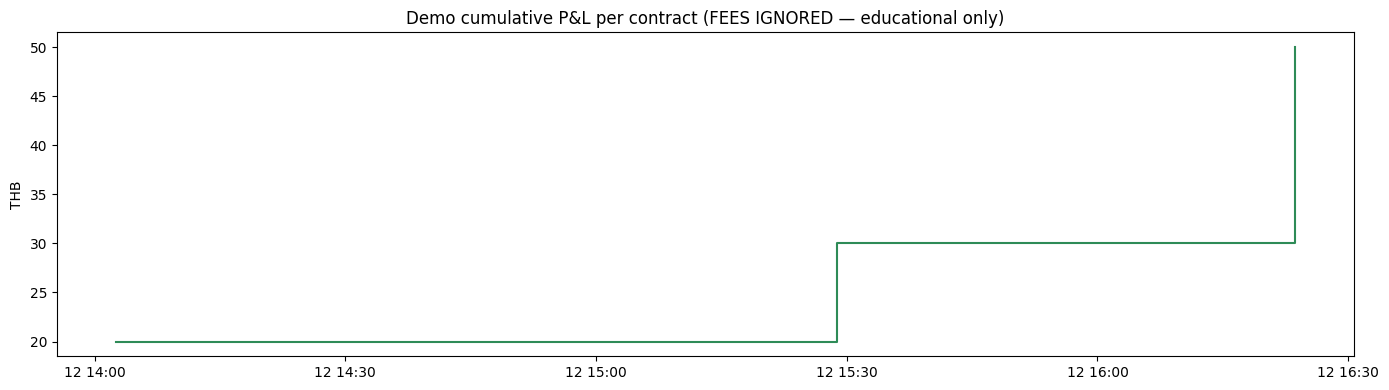

Demo position still open at end of data: short_usdt_binance_long_tfex since 2026-06-12 16:38:18.537800+07:00


In [9]:
demo_trades, demo_open = run_backtest(pairs, round_trip_cost=0.0,
                                      entry_buffer=0.02, exit_tolerance=0.01)
print(f"Demo trades (fees ignored): {len(demo_trades)}")
if not demo_trades.empty:
    demo_trades["cum_pnl_per_contract"] = demo_trades.pnl_thb_per_contract.cumsum()
    show = demo_trades[["side", "entry_ts", "entry_edge", "exit_ts", "exit_edge",
                        "pnl_thb_per_usd", "pnl_thb_per_contract"]].head(20).copy()
    num_cols = show.select_dtypes("number").columns
    show[num_cols] = show[num_cols].round(4)
    display(show)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.step(demo_trades.exit_ts, demo_trades.cum_pnl_per_contract, where="post", color="seagreen")
    ax.set_title("Demo cumulative P&L per contract (FEES IGNORED — educational only)")
    ax.set_ylabel("THB")
    plt.tight_layout()
    plt.show()
if demo_open is not None:
    print(f"Demo position still open at end of data: {demo_open['side']} since {demo_open['entry_ts']}")

## What-if: how much the fee tier matters

Same strategy, same real data — only the Binance fee rate changes.

In [10]:
rows = []
for fee in [0.0025, 0.0010, 0.0005, 0.0]:
    rt = 2 * fee * avg_price + 2 * TFEX_COST_PER_SIDE_THB
    t, _ = run_backtest(pairs, rt, ENTRY_BUFFER_THB, EXIT_TOLERANCE_THB)
    rows.append({"binance_fee_per_side": f"{fee:.2%}",
                 "round_trip_cost_thb_per_usd": round(rt, 4),
                 "trades": len(t),
                 "total_pnl_thb_per_contract": round(t.pnl_thb_per_contract.sum(), 0) if len(t) else 0})
pd.DataFrame(rows)

,binance_fee_per_side,round_trip_cost_thb_per_usd,trades,total_pnl_thb_per_contract
0,0.25%,0.2136,0,0
1,0.10%,0.1154,0,0
2,0.05%,0.0827,0,0
3,0.00%,0.0500,0,0


## Step 8 — Liquidity: how much money can this strategy use?

The spread tells you **when** to trade. The **orderbook depth** tells you **how big** you can trade.

An orderbook has levels. Level 1 = the best price. Deeper levels = worse prices:

```text
        BID side (buyers)          ASK side (sellers)
level 1: best (highest) bid        best (lowest) ask
level 2: a bit lower               a bit higher
...                                ...
level 10: much lower               much higher
```

Your database saves **10 levels for every snapshot** (`bidask_levels` table, and the
`latest_bidask_10_levels` view you can see in your DB browser).

**Two rules for this pair trade:**

1. **Units are different on each venue.** TFEX volume = *contracts* (1 contract = 1,000 USD).
   Binance volume = *USDT* (≈ 1 USD each). Always convert to USD before comparing.
2. **You trade both venues at the same time**, so your maximum size = the **smaller** side:

```text
max_size_short_usdt = min(Binance bid depth, TFEX ask depth)   # sell Binance, buy TFEX
max_size_long_usdt  = min(Binance ask depth, TFEX bid depth)   # buy Binance, sell TFEX
```

In [11]:
# Latest full 10-level ladder for both venues (same data as the latest_bidask_10_levels view)
conn = psycopg2.connect(os.environ["DATABASE_URL"])
ladder = pd.read_sql("""
SELECT source, symbol, received_at, level,
       bid_price, bid_volume, ask_price, ask_volume
FROM latest_bidask_10_levels
WHERE (source = 'settrade'   AND symbol = %(tfex)s)
   OR (source = 'binance_th' AND symbol = %(binance)s)
ORDER BY source, level
""", conn, params={"tfex": TFEX_SYMBOL, "binance": BINANCE_SYMBOL})
conn.close()

ladder["received_at"] = pd.to_datetime(ladder["received_at"], utc=True).dt.tz_convert("Asia/Bangkok")
for col in ["bid_price", "bid_volume", "ask_price", "ask_volume"]:
    ladder[col] = ladder[col].astype(float)

# Convert raw volume to USD so both venues are comparable
ladder["usd_per_unit"] = ladder.source.map({"settrade": 1000.0, "binance_th": 1.0})
ladder["bid_usd"] = ladder.bid_volume * ladder.usd_per_unit
ladder["ask_usd"] = ladder.ask_volume * ladder.usd_per_unit

for source, grp in ladder.groupby("source"):
    unit = "contracts (1 = 1,000 USD)" if source == "settrade" else "USDT (~1 USD)"
    print(f"\n=== {source} {grp.symbol.iloc[0]} | snapshot: {grp.received_at.iloc[0]} | raw volume unit: {unit} ===")
    view = grp[["level", "bid_usd", "bid_price", "ask_price", "ask_usd"]].set_index("level").round(2)
    display(view)
    print(f"   Total bid depth (10 levels): {grp.bid_usd.sum():>12,.0f} USD")
    print(f"   Total ask depth (10 levels): {grp.ask_usd.sum():>12,.0f} USD")


=== binance_th USDTTHB | snapshot: 2026-06-12 17:00:27.472116+07:00 | raw volume unit: USDT (~1 USD) ===


,bid_usd,bid_price,ask_price,ask_usd
level,,,,
1,73659.0,32.68,32.69,123239.0
2,184933.0,32.67,32.70,30730.0
3,26410.0,32.65,32.71,91498.0
4,256010.0,32.64,32.75,1391.0
5,7425.0,32.63,32.76,30926.0
6,3320.0,32.62,32.77,237992.0
7,64426.0,32.61,32.78,60.0
8,11372.0,32.60,32.79,20060.0
9,883.0,32.59,32.80,206.0


   Total bid depth (10 levels):      649,315 USD
   Total ask depth (10 levels):      566,172 USD

=== settrade USDM26 | snapshot: 2026-06-12 16:58:20.126154+07:00 | raw volume unit: contracts (1 = 1,000 USD) ===


,bid_usd,bid_price,ask_price,ask_usd
level,,,,
1,9000.0,32.62,32.64,7000.0
2,65000.0,32.61,32.65,77000.0
3,1274000.0,32.60,32.66,4000.0
4,46000.0,32.59,32.67,1000.0
5,96000.0,32.58,32.68,6000.0
6,0.0,0.00,0.00,0.0
7,0.0,0.00,0.00,0.0
8,0.0,0.00,0.00,0.0
9,0.0,0.00,0.00,0.0


   Total bid depth (10 levels):    1,490,000 USD
   Total ask depth (10 levels):       95,000 USD


### Depth over time — the real answer to "how much money can I use?"

One snapshot can lie (depth appears and disappears). So we measure the **whole window**:
for every matched moment, the USD depth at level 1 and at the top 5 levels, on the side
each strategy direction must trade.

In [12]:
conn = psycopg2.connect(os.environ["DATABASE_URL"])
DEPTH_QUERY = """
SELECT s.source, s.received_at,
  SUM(l.volume) FILTER (WHERE l.side = 'bid' AND l.level = 1)  AS bid_l1,
  SUM(l.volume) FILTER (WHERE l.side = 'ask' AND l.level = 1)  AS ask_l1,
  SUM(l.volume) FILTER (WHERE l.side = 'bid' AND l.level <= 5) AS bid_l5,
  SUM(l.volume) FILTER (WHERE l.side = 'ask' AND l.level <= 5) AS ask_l5
FROM bidask_snapshots s
JOIN bidask_levels l ON l.snapshot_id = s.id
WHERE (s.source = 'settrade'   AND s.symbol = %(tfex)s)
   OR (s.source = 'binance_th' AND s.symbol = %(binance)s)
GROUP BY s.id, s.source, s.received_at
ORDER BY s.received_at
"""
depth = pd.read_sql(DEPTH_QUERY, conn, params={"tfex": TFEX_SYMBOL, "binance": BINANCE_SYMBOL})
conn.close()

depth["received_at"] = pd.to_datetime(depth["received_at"], utc=True).dt.tz_convert("Asia/Bangkok")
vol_cols = ["bid_l1", "ask_l1", "bid_l5", "ask_l5"]
usd_mult = depth.source.map({"settrade": 1000.0, "binance_th": 1.0})
for c in vol_cols:
    depth[c] = depth[c].astype(float) * usd_mult     # now everything is USD

tfex_depth = (depth[depth.source == "settrade"][["received_at"] + vol_cols]
              .rename(columns={c: f"tfex_{c}" for c in vol_cols}).sort_values("received_at"))
binance_depth = (depth[depth.source == "binance_th"][["received_at"] + vol_cols]
                 .rename(columns={c: f"binance_{c}" for c in vol_cols}).sort_values("received_at"))

depth_pairs = pd.merge_asof(binance_depth, tfex_depth, on="received_at",
                            direction="backward",
                            tolerance=pd.Timedelta(seconds=MAX_QUOTE_AGE_SECONDS)).dropna()

# Max instant size = the smaller venue, per direction
depth_pairs["max_usd_short_l1"] = depth_pairs[["binance_bid_l1", "tfex_ask_l1"]].min(axis=1)
depth_pairs["max_usd_long_l1"]  = depth_pairs[["binance_ask_l1", "tfex_bid_l1"]].min(axis=1)
depth_pairs["max_usd_short_l5"] = depth_pairs[["binance_bid_l5", "tfex_ask_l5"]].min(axis=1)
depth_pairs["max_usd_long_l5"]  = depth_pairs[["binance_ask_l5", "tfex_bid_l5"]].min(axis=1)

size_cols = ["max_usd_short_l1", "max_usd_long_l1", "max_usd_short_l5", "max_usd_long_l5"]
print("Maximum instant trade size, in USD (whole window):\n")
print(depth_pairs[size_cols].describe().round(0).to_string())

typical = depth_pairs[size_cols].median()
avg_px = pairs.binance_mid.mean()
print(f"\nTypical (median) size you can trade instantly:")
print(f"  short direction, level 1 only : {typical.max_usd_short_l1:>10,.0f} USD  (~{typical.max_usd_short_l1 * avg_px:,.0f} THB, ~{typical.max_usd_short_l1 / 1000:.0f} TFEX contracts)")
print(f"  long  direction, level 1 only : {typical.max_usd_long_l1:>10,.0f} USD  (~{typical.max_usd_long_l1 * avg_px:,.0f} THB, ~{typical.max_usd_long_l1 / 1000:.0f} TFEX contracts)")
print(f"  short direction, top 5 levels : {typical.max_usd_short_l5:>10,.0f} USD")
print(f"  long  direction, top 5 levels : {typical.max_usd_long_l5:>10,.0f} USD")

# Which venue is the bottleneck (the smaller side)?
short_bottleneck = (depth_pairs.tfex_ask_l1 < depth_pairs.binance_bid_l1).mean()
long_bottleneck = (depth_pairs.tfex_bid_l1 < depth_pairs.binance_ask_l1).mean()
print(f"\nTFEX is the bottleneck {short_bottleneck:.0%} of the time (short direction) "
      f"and {long_bottleneck:.0%} (long direction).")

Maximum instant trade size, in USD (whole window):

       max_usd_short_l1  max_usd_long_l1  max_usd_short_l5  max_usd_long_l5
count            7648.0           7648.0            7648.0           7648.0
mean           156743.0         177474.0          583591.0         634455.0
std            147025.0         138323.0          220422.0         199227.0
min                17.0              4.0           95000.0         111069.0
25%             42649.0          66000.0          409680.0         492848.0
50%            108840.0         159384.0          535071.0         675128.0
75%            238000.0         285417.0          793182.0         792006.0
max            653612.0         620150.0         1124574.0         886039.0

Typical (median) size you can trade instantly:
  short direction, level 1 only :    108,840 USD  (~3,560,749 THB, ~109 TFEX contracts)
  long  direction, level 1 only :    159,384 USD  (~5,214,319 THB, ~159 TFEX contracts)
  short direction, top 5 levels :    535

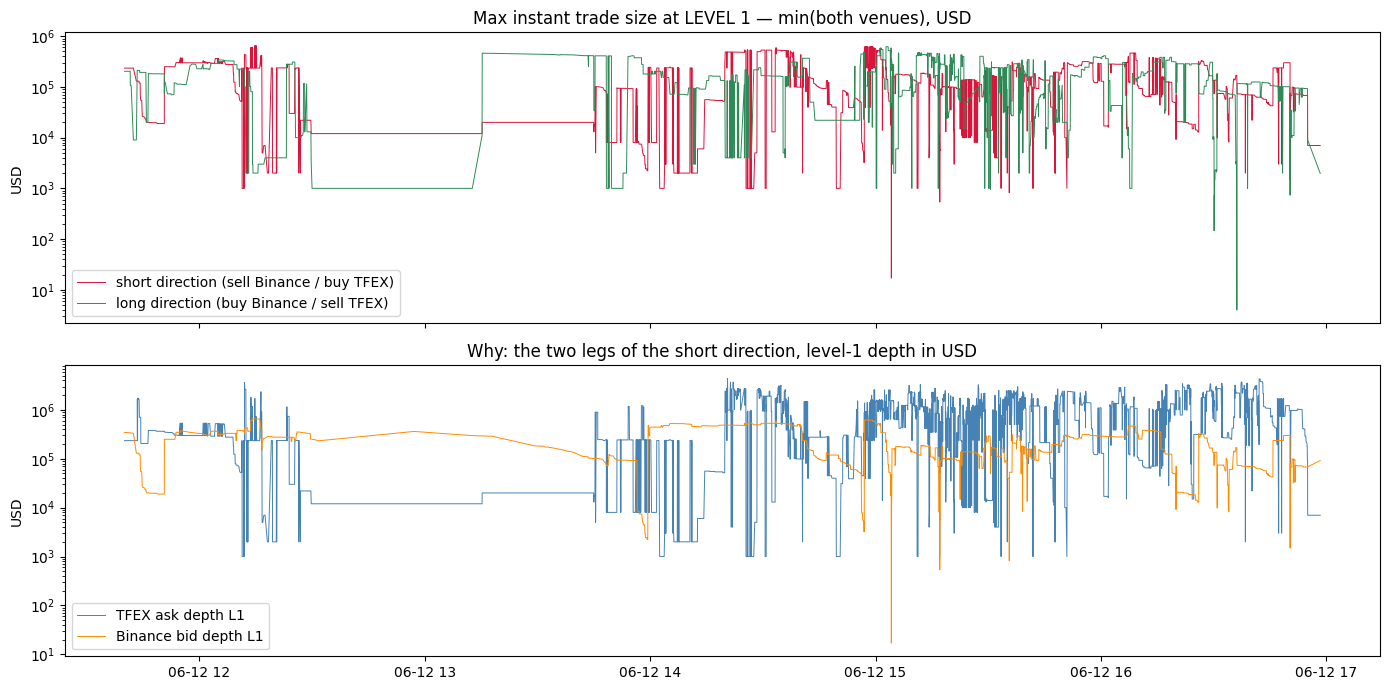

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ts = depth_pairs.received_at

axes[0].plot(ts, depth_pairs.max_usd_short_l1, color="crimson", lw=0.7, label="short direction (sell Binance / buy TFEX)")
axes[0].plot(ts, depth_pairs.max_usd_long_l1, color="seagreen", lw=0.7, label="long direction (buy Binance / sell TFEX)")
axes[0].set_title("Max instant trade size at LEVEL 1 — min(both venues), USD")
axes[0].set_ylabel("USD")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(ts, depth_pairs.tfex_ask_l1, color="steelblue", lw=0.7, label="TFEX ask depth L1")
axes[1].plot(ts, depth_pairs.binance_bid_l1, color="darkorange", lw=0.7, label="Binance bid depth L1")
axes[1].set_title("Why: the two legs of the short direction, level-1 depth in USD")
axes[1].set_ylabel("USD")
axes[1].set_yscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()

### Slippage — what happens when your order is bigger than level 1

If your order is bigger than level 1, you "walk the book": part of the order fills at level 2,
3, ... at worse prices. The average fill price moves against you. This is **slippage**, and it is
a real cost just like fees.

Below we walk the latest real ladder with different order sizes.

In [14]:
def walk_book(levels: list[tuple[float, float]], usd_size: float) -> float | None:
    """Average fill price when buying/selling `usd_size` USD into `levels` [(price, usd_depth), ...].
    Returns None if the 10 visible levels are not deep enough."""
    remaining, cost = usd_size, 0.0
    for price, usd_depth in levels:
        take = min(remaining, usd_depth)
        cost += take * price
        remaining -= take
        if remaining <= 0:
            return cost / usd_size
    return None


def ladder_side(source: str, side: str) -> list[tuple[float, float]]:
    g = ladder[ladder.source == source].sort_values("level")
    return list(zip(g[f"{side}_price"], g[f"{side}_usd"]))


SIDES = [
    ("binance_th", "bid", "sell USDT on Binance"),
    ("binance_th", "ask", "buy USDT on Binance"),
    ("settrade", "ask", "buy futures on TFEX"),
    ("settrade", "bid", "sell futures on TFEX"),
]

rows = []
for usd_size in [1_000, 5_000, 10_000, 25_000, 50_000, 100_000]:
    row = {"order_size_usd": f"{usd_size:,}"}
    for source, side, label in SIDES:
        levels = ladder_side(source, side)
        avg = walk_book(levels, usd_size)
        if avg is None:
            row[label] = "not enough depth"
        else:
            best = levels[0][0]
            slip = (avg - best) if side == "ask" else (best - avg)   # always >= 0 = cost
            row[label] = f"{avg:.4f} (slip {slip:.4f})"
    rows.append(row)

print("Average fill price (and slippage in THB per USD) using the LATEST real orderbook:\n")
display(pd.DataFrame(rows).set_index("order_size_usd"))
print("Remember: the typical edge in this data is only 0.01-0.03 THB per USD.")
print("If slippage is 0.01 THB, half or all of the edge is gone before fees.")

Average fill price (and slippage in THB per USD) using the LATEST real orderbook:



,sell USDT on Binance,buy USDT on Binance,buy futures on TFEX,sell futures on TFEX
order_size_usd,,,,
"1,000",32.6800 (slip 0.0000),32.6900 (slip 0.0000),32.6400 (slip 0.0000),32.6200 (slip 0.0000)
"5,000",32.6800 (slip 0.0000),32.6900 (slip 0.0000),32.6400 (slip 0.0000),32.6200 (slip 0.0000)
"10,000",32.6800 (slip 0.0000),32.6900 (slip 0.0000),32.6430 (slip 0.0030),32.6190 (slip 0.0010)
"25,000",32.6800 (slip 0.0000),32.6900 (slip 0.0000),32.6472 (slip 0.0072),32.6136 (slip 0.0064)
"50,000",32.6800 (slip 0.0000),32.6900 (slip 0.0000),32.6486 (slip 0.0086),32.6118 (slip 0.0082)
"100,000",32.6774 (slip 0.0026),32.6900 (slip 0.0000),not enough depth,32.6083 (slip 0.0117)


Remember: the typical edge in this data is only 0.01-0.03 THB per USD.
If slippage is 0.01 THB, half or all of the edge is gone before fees.


### Liquidity lesson for students

1. **The spread tells you *when*, the depth tells you *how much*.** A beautiful 0.1% spread on
   10 USDT of depth is worth almost nothing.
2. **Your max size = the smaller venue, and the bottleneck switches.** In this window TFEX was the
   smaller side ~40% of the time and Binance ~60% — you must check **both** books every time, not
   assume one venue is always deep.
3. **Depth changes second by second.** The median instant size here was large (100,000+ USD), but
   the minimum dropped to almost nothing — liquidity can vanish exactly when the spread spikes.
4. **Convert units first.** TFEX volume is in contracts (×1,000 USD), Binance in USDT. Comparing
   raw numbers gives nonsense.
5. **Slippage is a cost.** Going deeper than level 1 moves your average price against you. Edge
   must beat fees **+ slippage at your size**, not just fees.
6. **TFEX trades in whole contracts.** Minimum size step = 1,000 USD, so your Binance leg should
   be a multiple of ~1,000 USDT to stay matched. (Note: the Settrade feed itself sends levels 6–10
   as zero — verified against the raw payload — so only 5 real TFEX levels are visible.)

## Honest conclusion

- The strategy itself is simple and correct: **enter when the gap pays more than all costs, exit
  when the gap is gone.** No z-score, no statistics — just THB, % and fees.
- Whether it makes money depends on two things only:
  1. **Your Binance fee tier** — at 0.25%/side the round-trip cost (~0.21 THB/USD) is far bigger
     than the typical gap (~0.01–0.03 THB/USD). At maker/VIP rates the math changes completely.
  2. **Episodic spikes** — the quiet state is near-zero spread. The opportunity is the rare wide
     moment (your 27 May 2026 chart). You need the logger running so the data is there when it happens.
- **Liquidity caps your size**: the strategy can only be as big as the smaller orderbook side at
  that moment — typically 100,000+ USD in this window, but sometimes almost zero. Check both
  books before sizing; bigger orders pay slippage on top of fees.
- Keep the Railway logger running. Re-run this notebook after a few days/weeks of data —
  every cell adapts automatically to the longer window.
- Before any real order: read the checklist in `ARBITRAGE_TUTORIAL.md`, confirm your real fee tier,
  and start with 1 contract maximum.